# LSTM vs 1D CNN — Daily Adidas Forecasting

**Uma Desai — COMP 541 Adidas Sales Project**

**Goal.** Predict daily store busyness (number of transactions per day) and minimize **MAPE** while maintaining **high directional accuracy** (predicting up vs down days correctly).

**What We changed from the previous version**
1. **Target switched from `Profit` to `transactions`** — busyness signal so MAPE is interpretable and not blown up by zero-profit days.
2. **Calendar + lag features** added (day-of-week cyclical, weekend, month seasonality, lag-7, rolling-7/28 means). Models are now multivariate instead of univariate.
3. **Loss switched to Huber** — more robust than MSE to spiky/zero-traffic days.
4. **Window 10 to 14** to capture weekly seasonality; bigger LSTM (50 → 64 units); LR scheduler added.
5. **Walk-forward cross-validation** instead of a single 80/20 split — hyperparameters are tuned on 3–5 different time slices.
6. **Two new metrics**: **SMAPE** (stable near zero) and **directional accuracy** (% of days where up/down direction is correct).
7. **Simple baselines** (yesterday / same-day-last-week / train-mean) — the deep model has to beat these to be worth the complexity.

All logic lives in `src/models.py`; this notebook just imports and runs it.

In [1]:
# Wire up the src/ folder so we can import the team's modules
import sys, os
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from data_preprocessing import load_data, data_cleaning
from models import (
    TARGET_COL, CALENDAR_FEATURES,
    build_feature_frame, chronological_split,
    build_lstm, train_lstm,
    build_cnn, train_cnn,
    evaluate_on_test, baseline_metrics,
    walk_forward_cv, tune_hyperparameters,
    plot_loss_curves, plot_predictions,
)
print("Modules loaded.")

Modules loaded.


## 1. Load, engineer features, split chronologically

`build_feature_frame` aggregates the transaction-level data to daily transaction count and adds calendar + lag/rolling features. We drop the first ~28 rows so all lag/rolling features are defined.

In [2]:
TARGET = "transactions"   # daily count of orders == 'busyness'
WINDOW = 14               # 2 weeks captures weekly seasonality cleanly
EPOCHS = 100
SEED = 42

df = load_data()
df = data_cleaning(df)

daily, FEATURE_COLS = build_feature_frame(
    df, target=TARGET, use_calendar=True,
    lags=(7,), rolling_windows=(7, 28),
)
daily_train, daily_test = chronological_split(daily, train_frac=0.8)

print(f"Daily series : {len(daily)} days  ({daily.index.min().date()} -> {daily.index.max().date()})")
print(f"Train        : {len(daily_train):4d} days")
print(f"Test (held)  : {len(daily_test):4d} days")
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(f"\nTarget stats:  mean={daily[TARGET_COL].mean():.2f}  "
      f"std={daily[TARGET_COL].std():.2f}  "
      f"min={daily[TARGET_COL].min():.0f}  max={daily[TARGET_COL].max():.0f}")
print(f"Zero-traffic days in test: {(daily_test[TARGET_COL] == 0).sum()} "
      f"({100*(daily_test[TARGET_COL] == 0).mean():.1f}%)")

Daily series : 975 days  (2023-01-30 -> 2025-09-30)
Train        :  780 days
Test (held)  :  195 days
Features (10): ['y', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend', 'day_of_month', 'lag_7', 'roll7_mean', 'roll28_mean']

Target stats:  mean=1.20  std=1.03  min=0  max=5
Zero-traffic days in test: 63 (32.3%)


## 2. Architecture — LSTM (multivariate)

Multivariate LSTM with 64 hidden units, Huber loss, light L2 (0.001) regularization. Inputs are sliding windows of shape `(window, n_features)`.

In [3]:
build_lstm(window=WINDOW, n_features=len(FEATURE_COLS)).summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 64)                19200     
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense (Dense)               (None, 1)                 65        
                                                                 
Total params: 19,265
Trainable params: 19,265
Non-trainable params: 0
_________________________________________________________________


In [4]:
lstm_model, lstm_history, lstm_x_scaler, lstm_y_scaler, _ = train_lstm(
    daily_train,
    feature_cols=FEATURE_COLS, window=WINDOW,
    hidden_units=64, dropout=0.20, l2_coeff=0.001, lr=1e-3, loss="huber",
    epochs=EPOCHS, batch_size=32, val_frac=0.20,
    early_stop_patience=15, seed=SEED, verbose=0,
)
lstm_metrics, lstm_preds = evaluate_on_test(
    lstm_model, lstm_x_scaler, lstm_y_scaler, FEATURE_COLS,
    daily_train, daily_test, window=WINDOW,
)
print(f"LSTM trained for {len(lstm_history.history['loss'])} epochs")
print(f"Final training loss  : {lstm_history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {lstm_history.history['val_loss'][-1]:.4f}\n")
print("LSTM test metrics:")
for k, v in lstm_metrics.items():
    print(f"  {k:>22s}: {v:,.4f}" if isinstance(v, float) else f"  {k:>22s}: {v}")

LSTM trained for 100 epochs
Final training loss  : 0.0222
Final validation loss: 0.0207

LSTM test metrics:
                    rmse: 1.0205
                     mae: 0.8570
                mape_pct: 34.6850
               smape_pct: 91.9802
     directional_acc_pct: 43.6620
         mae_pct_of_mean: 75.9620
                      r2: -0.0266
           n_test_points: 195


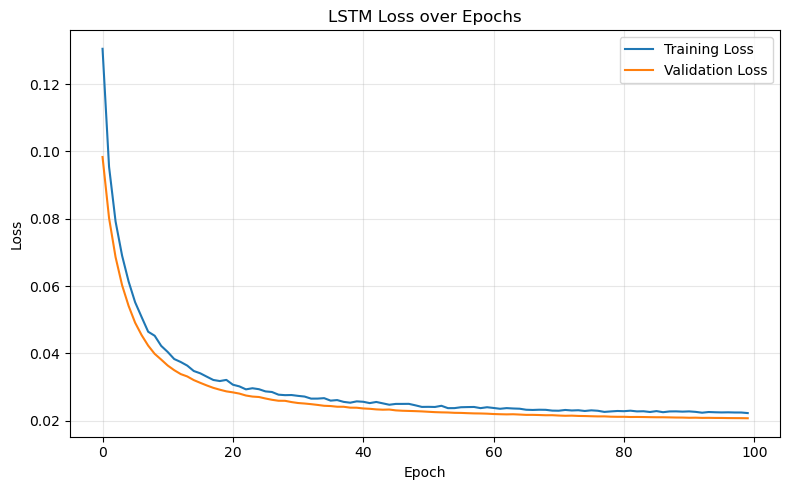

In [5]:
os.makedirs("figures", exist_ok=True)
plot_loss_curves(lstm_history, save_path="figures/loss_curve.png", model_name="LSTM")
plt.show()

## 3. Architecture — 1D CNN (multivariate)

Two causal Conv1D blocks (32 to 64 filters), global average pool, dense head. Same loss and regularization as the LSTM for a fair comparison.

In [6]:
build_cnn(window=WINDOW, n_features=len(FEATURE_COLS)).summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d (Conv1D)             (None, 14, 32)            992       
                                                                 
 dropout_2 (Dropout)         (None, 14, 32)            0         
                                                                 
 conv1d_1 (Conv1D)           (None, 14, 64)            6208      
                                                                 
 global_average_pooling1d (G  (None, 64)               0         
 lobalAveragePooling1D)                                          
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                      

In [7]:
cnn_model, cnn_history, cnn_x_scaler, cnn_y_scaler, _ = train_cnn(
    daily_train,
    feature_cols=FEATURE_COLS, window=WINDOW,
    filters=(32, 64), kernel_size=3,
    dropout=0.20, l2_coeff=0.001, lr=1e-3, loss="huber",
    epochs=EPOCHS, batch_size=32, val_frac=0.20,
    early_stop_patience=15, seed=SEED, verbose=0,
)
cnn_metrics, cnn_preds = evaluate_on_test(
    cnn_model, cnn_x_scaler, cnn_y_scaler, FEATURE_COLS,
    daily_train, daily_test, window=WINDOW,
)
print(f"CNN trained for {len(cnn_history.history['loss'])} epochs")
print(f"Final training loss  : {cnn_history.history['loss'][-1]:.4f}")
print(f"Final validation loss: {cnn_history.history['val_loss'][-1]:.4f}\n")
print("CNN test metrics:")
for k, v in cnn_metrics.items():
    print(f"  {k:>22s}: {v:,.4f}" if isinstance(v, float) else f"  {k:>22s}: {v}")

CNN trained for 100 epochs
Final training loss  : 0.0218
Final validation loss: 0.0200

CNN test metrics:
                    rmse: 1.0139
                     mae: 0.8476
                mape_pct: 33.6657
               smape_pct: 91.5853
     directional_acc_pct: 49.2958
         mae_pct_of_mean: 75.1274
                      r2: -0.0134
           n_test_points: 195


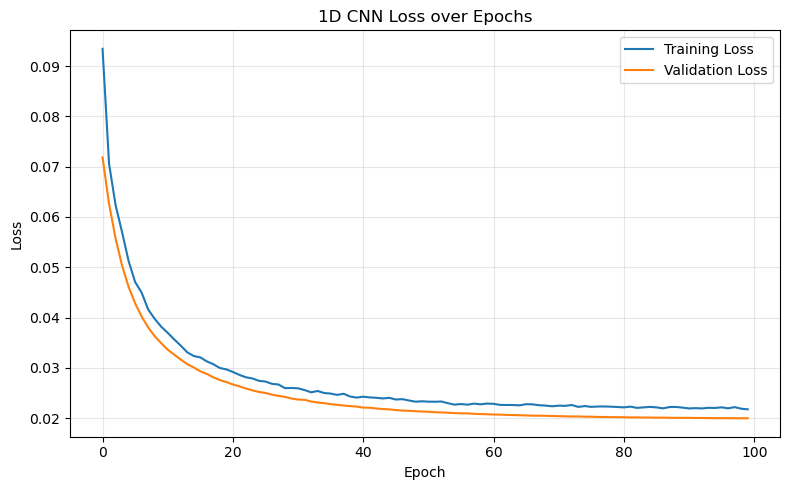

In [8]:
plot_loss_curves(cnn_history, save_path="figures/cnn_loss_curve.png", model_name="1D CNN")
plt.show()

## 4. Head-to-head comparison vs simple baselines

Any deep model must beat *yesterday's value* and *same-day-last-week* to be worth the complexity.

In [9]:
baselines = baseline_metrics(daily_train, daily_test)
print("Baseline forecasters on the held-out test set:")
display(baselines.round(3))

summary = pd.DataFrame([
    {"model": "LSTM", **lstm_metrics},
    {"model": "1D CNN", **cnn_metrics},
]).set_index("model")
print("\nDeep models on the same test set:")
display(summary.round(3))

Baseline forecasters on the held-out test set:


,mae,rmse,mape_pct,smape_pct,directional_acc_pct
baseline,,,,,
yesterday,1.118,1.450,69.129,123.465,13.380
same_day_last_week,1.144,1.466,67.740,123.239,32.394
train_mean,0.844,1.011,33.566,91.553,0.000



Deep models on the same test set:


,rmse,mae,mape_pct,smape_pct,directional_acc_pct,mae_pct_of_mean,r2,n_test_points
model,,,,,,,,
LSTM,1.020,0.857,34.685,91.980,43.662,75.962,-0.027,195
1D CNN,1.014,0.848,33.666,91.585,49.296,75.127,-0.013,195


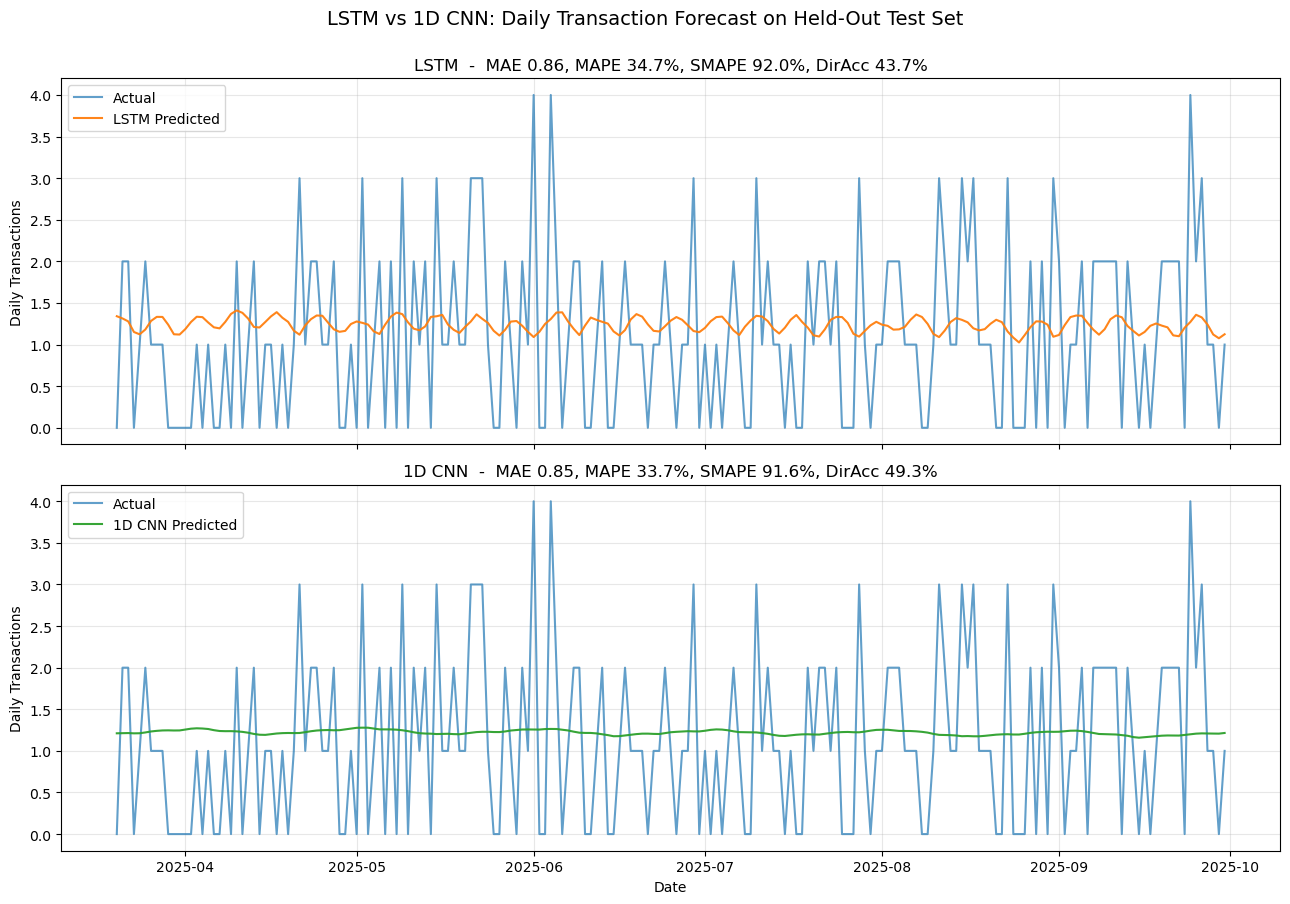

In [10]:
# Side-by-side prediction plots
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

for ax, preds, name, color, m in [
    (axes[0], lstm_preds, "LSTM",   "tab:orange", lstm_metrics),
    (axes[1], cnn_preds,  "1D CNN", "tab:green",  cnn_metrics),
]:
    ax.plot(preds.index, preds["actual"], label="Actual", alpha=0.7, color="tab:blue")
    ax.plot(preds.index, preds["predicted"], label=f"{name} Predicted", alpha=0.95, color=color)
    ax.set_title(
        f"{name}  -  MAE {m['mae']:.2f}, MAPE {m['mape_pct']:.1f}%, "
        f"SMAPE {m['smape_pct']:.1f}%, DirAcc {m['directional_acc_pct']:.1f}%"
    )
    ax.set_ylabel("Daily Transactions")
    ax.legend(loc="upper left")
    ax.grid(alpha=0.3)
axes[1].set_xlabel("Date")
fig.suptitle("LSTM vs 1D CNN: Daily Transaction Forecast on Held-Out Test Set", y=1.00, fontsize=14)
fig.tight_layout()
fig.savefig("figures/lstm_vs_cnn_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Multi-seed evaluation

Trains both architectures across seeds 42, 123, 7 (six full training runs total) and produces a summary table. Run-to-run variance tells us if the differences between LSTM and CNN are real or just noise.

In [11]:
from models import run_multi_seed_comparison

multi = run_multi_seed_comparison(
    target=TARGET, window=WINDOW, epochs=EPOCHS,
    architectures=("lstm", "cnn"),
    seeds=(42, 123, 7),
    verbose=1,
)

print("\nPer-run results (one row per architecture x seed):")
display(multi["per_run_df"].round(3))

print("\nSummary table (mean ± std across seeds):")
display(multi["summary_df"])


Multi-seed run for LSTM (seeds=[42, 123, 7])
  [LSTM] seed=42 ...
  [LSTM] seed=123 ...
  [LSTM] seed=7 ...

Multi-seed run for CNN (seeds=[42, 123, 7])
  [CNN] seed=42 ...
  [CNN] seed=123 ...
  [CNN] seed=7 ...

Per-run results (one row per architecture x seed):


,architecture,seed,rmse,mae,mape_pct,smape_pct,directional_acc_pct,mae_pct_of_mean,r2,n_test_points
0,LSTM,42,1.021,0.855,34.527,91.997,42.958,75.810,-0.027,195
1,LSTM,123,1.020,0.854,34.425,91.984,43.662,75.704,-0.025,195
2,LSTM,7,1.020,0.857,34.700,92.007,44.366,75.966,-0.027,195
3,CNN,42,1.014,0.847,33.640,91.565,50.000,75.113,-0.013,195
4,CNN,123,1.016,0.852,34.033,91.624,51.408,75.549,-0.017,195
5,CNN,7,1.016,0.851,33.946,91.615,49.296,75.462,-0.017,195



Summary table (mean ± std across seeds):


,n_seeds,n_test_points,rmse,mae,mape_pct,smape_pct,directional_acc_pct,mae_pct_of_mean,r2
architecture,,,,,,,,,
LSTM,3,195,1.0203 ± 0.0004,0.8555 ± 0.0015,34.5505 ± 0.1392,91.9961 ± 0.0117,43.6620 ± 0.7042,75.8267 ± 0.1318,-0.0264 ± 0.0008
CNN,3,195,1.0151 ± 0.0011,0.8504 ± 0.0026,33.8732 ± 0.2063,91.6010 ± 0.0316,50.2347 ± 1.0757,75.3746 ± 0.2306,-0.0159 ± 0.0022


## 6. Walk-forward cross-validation

A single 80/20 split tells us how the model does on *one* slice of history — which can be misleading if that slice happens to be unusually easy or hard. `TimeSeriesSplit` expands the training window and tests on the next block, repeating across 5 folds to get the mean ± std for each metric.

In [12]:
wfcv_lstm = walk_forward_cv(
    daily, feature_cols=FEATURE_COLS, architecture="lstm",
    n_splits=5, window=WINDOW,
    hidden_units=64, dropout=0.20, l2_coeff=0.001, lr=1e-3, loss="huber",
    epochs=60, batch_size=32, early_stop_patience=10,
    seed=SEED, verbose=1,
)
wfcv_cnn = walk_forward_cv(
    daily, feature_cols=FEATURE_COLS, architecture="cnn",
    n_splits=5, window=WINDOW,
    filters=(32, 64), kernel_size=3,
    dropout=0.20, l2_coeff=0.001, lr=1e-3, loss="huber",
    epochs=60, batch_size=32, early_stop_patience=10,
    seed=SEED, verbose=1,
)

def _summarize(name, df):
    cols = ["mae", "mape_pct", "smape_pct", "directional_acc_pct", "r2"]
    return pd.Series(
        {c: f"{df[c].mean():.3f} ± {df[c].std(ddof=1):.3f}" for c in cols},
        name=name,
    )

cv_summary = pd.concat([_summarize("LSTM", wfcv_lstm), _summarize("1D CNN", wfcv_cnn)], axis=1).T
print("\nWalk-forward CV (5 folds) — mean ± std across folds:")
display(cv_summary)

print("\nPer-fold breakdown — LSTM:")
display(wfcv_lstm.round(3))
print("Per-fold breakdown — CNN:")
display(wfcv_cnn.round(3))

  fold 1/5: train=165 -> test=162
  fold 2/5: train=327 -> test=162
  fold 3/5: train=489 -> test=162
  fold 4/5: train=651 -> test=162
  fold 5/5: train=813 -> test=162
  fold 1/5: train=165 -> test=162
  fold 2/5: train=327 -> test=162
  fold 3/5: train=489 -> test=162
  fold 4/5: train=651 -> test=162
  fold 5/5: train=813 -> test=162

Walk-forward CV (5 folds) — mean ± std across folds:


,mae,mape_pct,smape_pct,directional_acc_pct,r2
LSTM,1.101 ± 0.598,62.343 ± 61.829,107.423 ± 51.124,47.820 ± 14.141,-1.007 ± 2.210
1D CNN,0.837 ± 0.032,36.789 ± 5.882,88.192 ± 8.792,51.532 ± 2.333,-0.063 ± 0.114



Per-fold breakdown — LSTM:


,fold,rmse,mae,mape_pct,smape_pct,directional_acc_pct,mae_pct_of_mean,r2,n_test_points
0,1,2.464,2.170,172.936,198.764,69.027,182.106,-4.961,162
1,2,1.080,0.863,35.839,81.411,49.153,65.298,-0.009,162
2,3,0.997,0.817,34.811,83.635,50.000,70.065,-0.016,162
3,4,0.979,0.799,33.502,84.932,31.092,72.318,-0.041,162
4,5,1.030,0.856,34.625,88.372,39.831,71.153,-0.010,162


Per-fold breakdown — CNN:


,fold,rmse,mae,mape_pct,smape_pct,directional_acc_pct,mae_pct_of_mean,r2,n_test_points
0,1,1.136,0.868,47.059,103.381,52.212,72.864,-0.266,162
1,2,1.079,0.846,34.241,81.499,53.390,64.008,-0.007,162
2,3,0.993,0.823,35.743,84.066,52.500,70.541,-0.009,162
3,4,0.975,0.790,32.214,84.121,52.101,71.478,-0.031,162
4,5,1.027,0.860,34.687,87.893,47.458,71.415,-0.003,162


## 7. Hyperparameter tuning (grid search + walk-forward CV)

Per the professor's feedback, we sweep over window length, learning rate, and capacity using walk-forward CV (3 folds per config). The configs are ranked by mean SMAPE across folds. SMAPE is preferred over plain MAPE for ranking because MAPE is unstable when the test set contains very low-traffic days.

In [13]:
lstm_grid = {
    "window":       [7, 14, 28],
    "lr":           [5e-4, 1e-3],
    "hidden_units": [32, 64],
}
lstm_tune = tune_hyperparameters(
    daily, feature_cols=FEATURE_COLS,
    architecture="lstm", grid=lstm_grid,
    n_splits=3, epochs=60, seed=SEED, verbose=1,
)
print("\nLSTM grid search results (sorted by mean SMAPE, lower is better):")
display(lstm_tune.round(3))

print(f"\nBest LSTM config:\n{lstm_tune.iloc[0].to_dict()}")

Tuning LSTM over 12 configs with 3-fold walk-forward CV

>> config: {'window': 7, 'lr': 0.0005, 'hidden_units': 32}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 7, 'lr': 0.0005, 'hidden_units': 64}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 7, 'lr': 0.001, 'hidden_units': 32}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 7, 'lr': 0.001, 'hidden_units': 64}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 14, 'lr': 0.0005, 'hidden_units': 32}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 14, 'lr': 0.0005, 'hidden_units': 64}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold

,window,lr,hidden_units,smape_mean,smape_std,mape_mean,mae_mean,dir_acc_mean
0,28,0.001,64,85.532,2.254,34.510,0.831,42.747
1,28,0.000,32,85.776,2.103,35.039,0.832,41.762
2,28,0.000,64,86.214,2.389,35.362,0.838,43.501
3,28,0.001,32,86.233,2.228,35.443,0.836,41.811
4,14,0.001,32,89.757,7.559,37.902,0.857,46.740
5,7,0.000,64,89.932,7.717,38.129,0.854,40.621
6,14,0.001,64,90.819,9.343,38.719,0.859,43.139
7,14,0.000,32,91.758,11.239,39.089,0.861,43.094
8,7,0.001,32,91.854,11.025,39.243,0.863,42.015
9,7,0.001,64,93.272,13.574,40.225,0.872,46.708



Best LSTM config:
{'window': 28.0, 'lr': 0.001, 'hidden_units': 64.0, 'smape_mean': 85.53194801012675, 'smape_std': 2.2541113705550706, 'mape_mean': 34.51011677583059, 'mae_mean': 0.8306670387585958, 'dir_acc_mean': 42.746997287872915}


In [14]:
cnn_grid = {
    "window":     [7, 14, 28],
    "lr":         [5e-4, 1e-3],
    "filters":    [(16, 32), (32, 64)],
}
cnn_tune = tune_hyperparameters(
    daily, feature_cols=FEATURE_COLS,
    architecture="cnn", grid=cnn_grid,
    n_splits=3, epochs=60, seed=SEED, verbose=1,
)
print("\nCNN grid search results (sorted by mean SMAPE, lower is better):")
display(cnn_tune.round(3))

print(f"\nBest CNN config:\n{cnn_tune.iloc[0].to_dict()}")

Tuning CNN over 12 configs with 3-fold walk-forward CV

>> config: {'window': 7, 'lr': 0.0005, 'filters': (16, 32)}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 7, 'lr': 0.0005, 'filters': (32, 64)}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 7, 'lr': 0.001, 'filters': (16, 32)}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 7, 'lr': 0.001, 'filters': (32, 64)}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 14, 'lr': 0.0005, 'filters': (16, 32)}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
  fold 3/3: train=732 -> test=243

>> config: {'window': 14, 'lr': 0.0005, 'filters': (32, 64)}
  fold 1/3: train=246 -> test=243
  fold 2/3: train=489 -> test=243
 

,window,lr,filters,smape_mean,smape_std,mape_mean,mae_mean,dir_acc_mean
0,14,0.000,"(16, 32)",84.242,2.217,31.665,0.799,48.710
1,14,0.000,"(32, 64)",85.078,2.326,33.957,0.821,50.570
2,14,0.001,"(32, 64)",85.799,2.192,34.929,0.831,49.059
3,28,0.001,"(32, 64)",86.020,2.673,35.576,0.832,48.493
4,28,0.000,"(16, 32)",86.533,3.391,34.758,0.822,51.311
5,14,0.001,"(16, 32)",86.930,3.753,35.363,0.832,50.769
6,7,0.000,"(32, 64)",87.283,3.759,36.126,0.840,48.698
7,7,0.000,"(16, 32)",87.941,5.147,35.797,0.835,48.314
8,28,0.001,"(16, 32)",87.979,5.715,36.058,0.831,47.122
9,7,0.001,"(32, 64)",88.447,4.954,37.437,0.851,49.617



Best CNN config:
{'window': 14, 'lr': 0.0005, 'filters': (16, 32), 'smape_mean': 84.24155513445537, 'smape_std': 2.2167058444193, 'mape_mean': 31.665141383806866, 'mae_mean': 0.7992130517959595, 'dir_acc_mean': 48.71037639731944}


## 8. Retrain best config on full training split and report final metrics

In [15]:
# Pull the winning config from each architecture's tuning table and retrain on the full
# train split, then evaluate on the held-out 20% test set.
best_lstm_cfg = lstm_tune.iloc[0]
best_cnn_cfg  = cnn_tune.iloc[0]

print(f"Best LSTM hyperparameters: {dict(best_lstm_cfg)}")
print(f"Best CNN  hyperparameters: {dict(best_cnn_cfg)}\n")

best_lstm_model, _, x_sc, y_sc, _ = train_lstm(
    daily_train, feature_cols=FEATURE_COLS,
    window=int(best_lstm_cfg["window"]),
    hidden_units=int(best_lstm_cfg["hidden_units"]),
    lr=float(best_lstm_cfg["lr"]),
    dropout=0.20, l2_coeff=0.001, loss="huber",
    epochs=EPOCHS, batch_size=32, early_stop_patience=15,
    seed=SEED, verbose=0,
)
best_lstm_metrics, best_lstm_preds = evaluate_on_test(
    best_lstm_model, x_sc, y_sc, FEATURE_COLS,
    daily_train, daily_test, window=int(best_lstm_cfg["window"]),
)

best_cnn_model, _, x_sc, y_sc, _ = train_cnn(
    daily_train, feature_cols=FEATURE_COLS,
    window=int(best_cnn_cfg["window"]),
    filters=tuple(best_cnn_cfg["filters"]),
    lr=float(best_cnn_cfg["lr"]),
    dropout=0.20, l2_coeff=0.001, loss="huber",
    epochs=EPOCHS, batch_size=32, early_stop_patience=15,
    seed=SEED, verbose=0,
)
best_cnn_metrics, best_cnn_preds = evaluate_on_test(
    best_cnn_model, x_sc, y_sc, FEATURE_COLS,
    daily_train, daily_test, window=int(best_cnn_cfg["window"]),
)

final = pd.DataFrame([
    {"model": "LSTM (tuned)", **best_lstm_metrics},
    {"model": "CNN  (tuned)", **best_cnn_metrics},
    {"model": "LSTM (default)", **lstm_metrics},
    {"model": "CNN  (default)", **cnn_metrics},
]).set_index("model")
print("Tuned vs default models on the held-out test set:")
display(final.round(3))

Best LSTM hyperparameters: {'window': 28.0, 'lr': 0.001, 'hidden_units': 64.0, 'smape_mean': 85.53194801012675, 'smape_std': 2.2541113705550706, 'mape_mean': 34.51011677583059, 'mae_mean': 0.8306670387585958, 'dir_acc_mean': 42.746997287872915}
Best CNN  hyperparameters: {'window': 14, 'lr': 0.0005, 'filters': (16, 32), 'smape_mean': 84.24155513445537, 'smape_std': 2.2167058444193, 'mape_mean': 31.665141383806866, 'mae_mean': 0.7992130517959595, 'dir_acc_mean': 48.71037639731944}

Tuned vs default models on the held-out test set:


,rmse,mae,mape_pct,smape_pct,directional_acc_pct,mae_pct_of_mean,r2,n_test_points
model,,,,,,,,
LSTM (tuned),1.017,0.852,34.313,91.827,40.845,75.507,-0.019,195
CNN (tuned),1.015,0.846,33.443,91.566,48.592,75.023,-0.016,195
LSTM (default),1.020,0.857,34.685,91.980,43.662,75.962,-0.027,195
CNN (default),1.014,0.848,33.666,91.585,49.296,75.127,-0.013,195
